In [5]:
import pandas as pd
df=pd.read_csv("/content/sample_data/4.Iris.csv")

In [6]:
print(df.shape)

(150, 6)


In [7]:
#Identify and handle outliers in at least three numerical columns of your choice
import numpy as np
from scipy import stats
#giving numerical manually because id also comes under numerical but it is not neede to analyse (outliers)
numerical=df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
#perform z test
#Any data point with a |Z-Score| > 3 is considered extremely rare (outlier) in a normal distribution.
zscore=stats.zscore(numerical)
outliers = (zscore > 3).all(axis=1)

# Invert the mask to KEEP non-outliers
df_clean = df[~outliers]


df=df_clean
df.shape

(150, 6)

In [8]:
#Determine the frequency distribution for at least two categorical columns.
categorical=['Species']
print(df[categorical[0]].value_counts())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [9]:

print("the mean is:",numerical.mean())
print("the meadian is: ",numerical.median())
print("the mode is: ",numerical.mode())

the mean is: SepalLengthCm    5.843333
SepalWidthCm     3.054000
PetalLengthCm    3.758667
PetalWidthCm     1.198667
dtype: float64
the meadian is:  SepalLengthCm    5.80
SepalWidthCm     3.00
PetalLengthCm    4.35
PetalWidthCm     1.30
dtype: float64
the mode is:     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.0           3.0            1.5           0.2


In [10]:
print("the standard deviation is: \n",numerical.std())
print("the interquartile range is: \n",numerical.quantile([0.25,0.50,0.75]))

the standard deviation is: 
 SepalLengthCm    0.828066
SepalWidthCm     0.433594
PetalLengthCm    1.764420
PetalWidthCm     0.763161
dtype: float64
the interquartile range is: 
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0.25            5.1           2.8           1.60           0.3
0.50            5.8           3.0           4.35           1.3
0.75            6.4           3.3           5.10           1.8


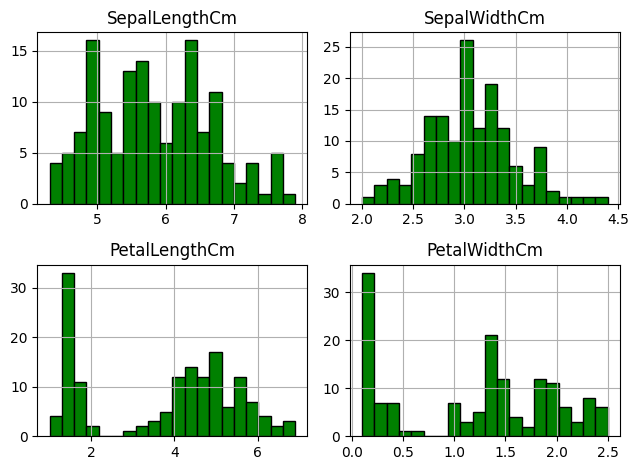

In [11]:
#histogram
import matplotlib.pyplot as plt

numerical.hist(bins=20,color='green',edgecolor='black')
plt.tight_layout()
plt.show()

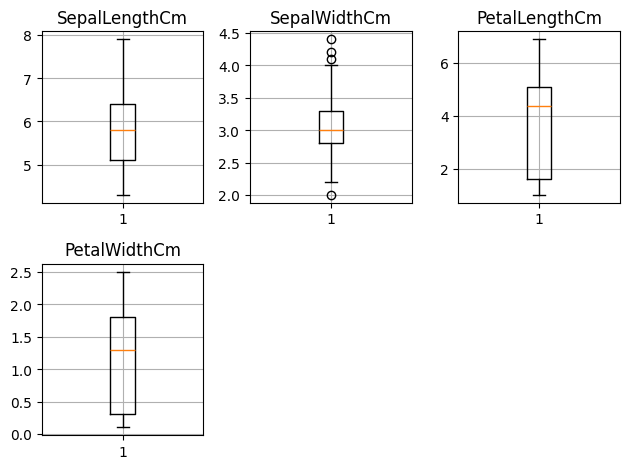

In [12]:
#box plot
features=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
for i, col in enumerate(features):
    plt.subplot(2, 3, i+1)
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.grid(True)
plt.tight_layout()
plt.show()

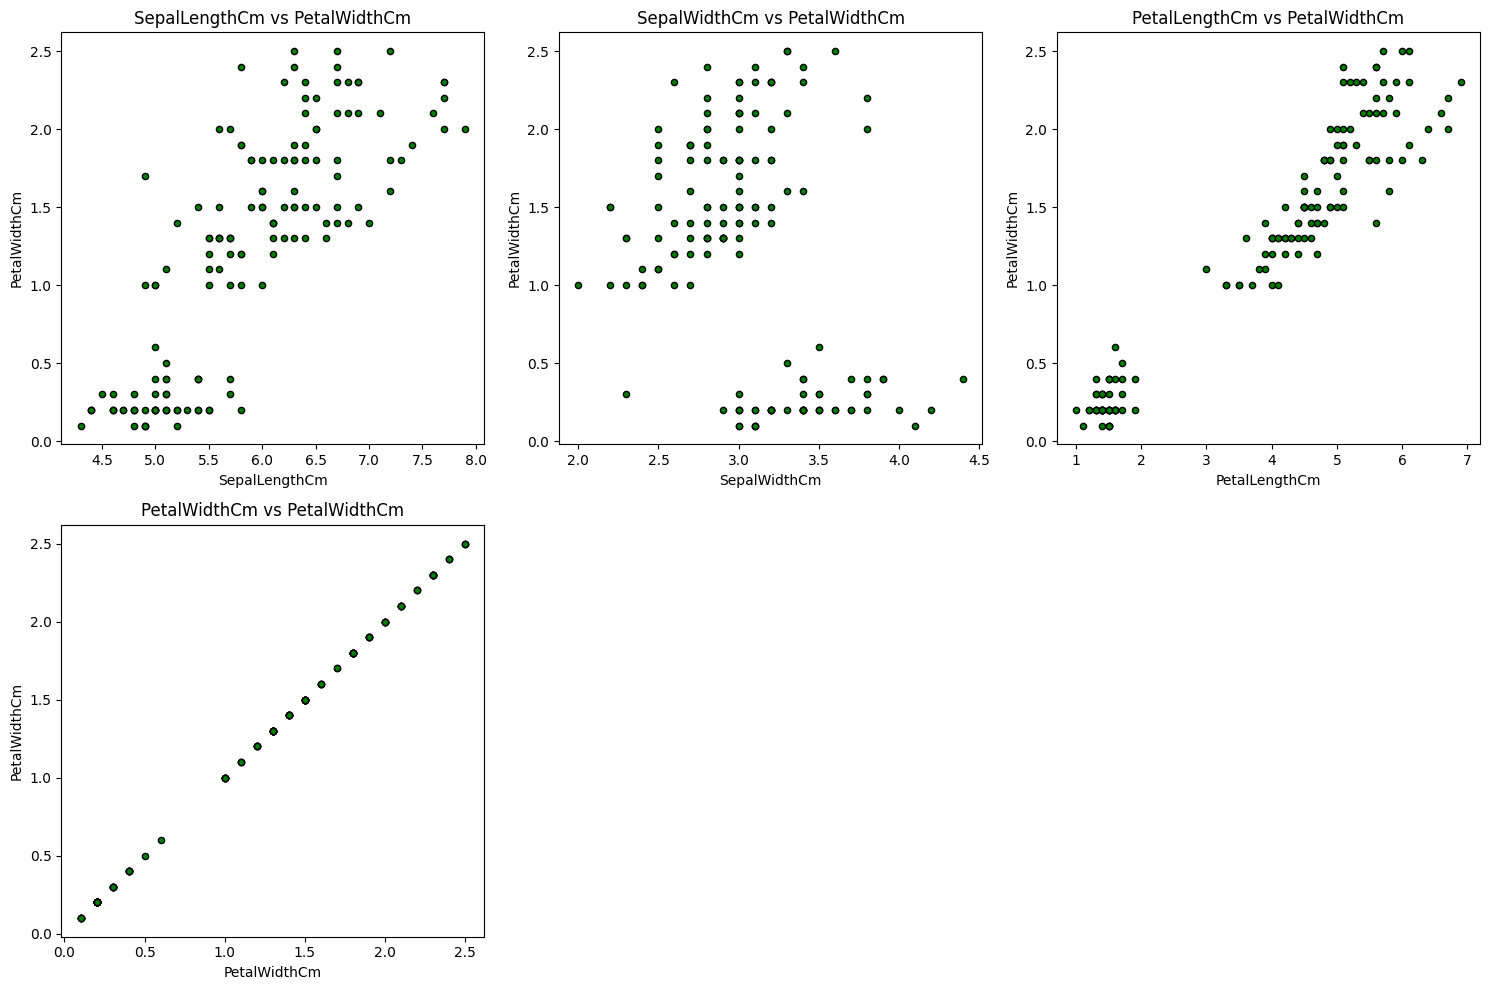

In [13]:
#scatter plot
features=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
target = 'PetalWidthCm'  # Replace with your target column

# Plot scatter plots for features vs target (Pandas style)
plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i+1)
    df.plot(kind='scatter', x=col, y=target, ax=plt.gca(), color='green', edgecolor='black')
    plt.title(f'{col} vs {target}')

plt.tight_layout()
plt.show()


In [14]:
#correlation matrix
correlationmatrix=numerical.corr()
print(correlationmatrix)

               SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
SepalLengthCm       1.000000     -0.109369       0.871754      0.817954
SepalWidthCm       -0.109369      1.000000      -0.420516     -0.356544
PetalLengthCm       0.871754     -0.420516       1.000000      0.962757
PetalWidthCm        0.817954     -0.356544       0.962757      1.000000


In [15]:
#Consider creating summary tables for categorical data to understand classdistributions.
summary_table=df['Species'].value_counts().to_frame('Count')
summary_table['Percentage']=(summary_table['Count']/summary_table['Count'].sum())
print(summary_table)

                 Count  Percentage
Species                           
Iris-setosa         50    0.333333
Iris-versicolor     50    0.333333
Iris-virginica      50    0.333333


# New Section